<div class="alert alert-block alert-primary" style="text-align: center;">

# 📚 Assignment  
# 🧪 Face Landmark Detection with Transfer Learning
</div>


Face landmark detection is the task of automatically identifying key points on a face (such as the corners of the eyes, tip of the nose, or edges of the mouth). These landmarks provide a structured representation of the face and are essential in applications ranging from emotion and expression analysis to augmented reality (e.g., filters and face tracking).  


In this task, you will apply **transfer learning** with a pre-trained **ResNet50** model to predict the 2D coordinates of facial landmarks.  
Using **PyTorch/PyTorch Lightning**, you will adapt ResNet (trained on ImageNet) to the more specialized domain of face geometry.

<p align="center">
  <img src="data/face_landmarks.png" width="65%" alt="Face Landmarks Example"/>
</p>





<p>
  <img src="https://upload.wikimedia.org/wikipedia/commons/0/04/ChatGPT_logo.svg" alt="ChatGPT Icon" width="28" style="vertical-align:middle; margin-right: 8px;">
  <strong>Use of GenAI: Required Declaration</strong>
</p>

> In this assessment, you **can use** generative AI tools to develop and deepen your understanding of your code — for example:
> - “Explain how this works to me”
> - “Help me find the bug in this code”
>
> You **may not use** GenAI to directly generate programs or solutions for submission.
>
> ---
>
> Any use of generative AI must be **explicitly acknowledged** by:
> - Stating the **prompts or questions** you used
> - Describing **how the output was used**
>
> On Moodle, you will find a designated textbox to report this information. This declaration is **mandatory** and ensures transparency in accordance with Monash University's academic integrity guidelines.
>
> ---
>
> ⚠️ **Important:** Failure to disclose permitted use — or using GenAI for prohibited tasks — may be treated as a breach of academic integrity.


## ⚠️ Before You Begin

This notebook contains the skeleton code to attempt the assignment. Feel free to add your own Markdown cells to include additional explanations, notes, or reflections.

Please follow the inline comments and Markdown instructions carefully.

- 🔒 **Do not modify any code blocks explicitly marked as “Do not change.”**  
- 🧠 **Use your own Markdown/Python cells if needed.**
- ✅ **Make sure to run all cells and generate outputs before submission.**

Good luck with the assignment!

In [1]:
## Libraries. Include if you need more.
import os
import numpy as np ## Numpy is the fundamental building block of understanding tensor (matrices) within Python
import matplotlib.pyplot as plt ## Matplotlib.pyplot is the graphing library that we will be using throughout the semester
# import sys ## Useful to retrieve some system information


# Torch libraries
import torch ## Pytorch is the deep learning library that we will be using
import torch.nn as nn ## Neural network module
import torch.nn.functional as F ## Functional module
import torch.optim as optim ## Optimization module
from torchvision import transforms

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import TensorDataset, DataLoader, Dataset


## Setting seeds for reproducibility. Do NOT change these!
RND_SEED = 42
np.random.seed(RND_SEED)
torch.manual_seed(RND_SEED)
torch.use_deterministic_algorithms(True)


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


<b>Enter you student details below</b>

- <b>Student Name:</b> Firstname Lastname
- <b>Student ID:</b> 123456789  

In [2]:
student_name = "Shang Chen" ## Replace with your name; eg., student_name = "Mehrtash Harandi"
student_id = "30586267" ## Replace with your student ID; eg., student_id = "123456789" 

The FLD data can be loaded in completely since it is relatively small. Have a look at how the data is loaded in to understand how to access the data for the modelling process. You do NOT have to edit the FLD_Data class!

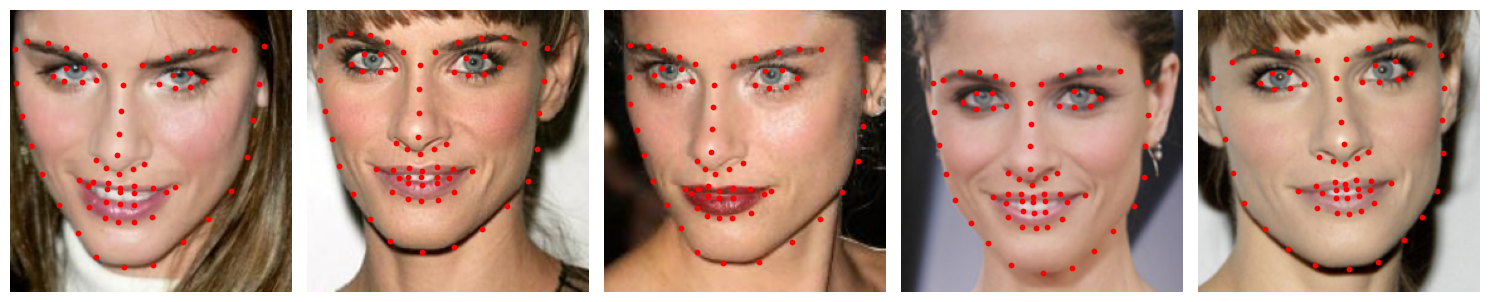

Train images shape: (680, 224, 224, 3)
Train landmarks shape: (680, 68, 2)
Validation images shape: (112, 224, 224, 3)
Validation landmarks shape: (112, 68, 2)
Test images shape: (200, 224, 224, 3)
Test landmarks shape: (200, 68, 2)


In [3]:
FLD_PATH = os.path.expanduser("data/FLD_dataset.npz") # <--- Change this path if you have stored the dataset in a different location

data = np.load(FLD_PATH)

train_imgs = data['train_images']
train_lms  = data['train_landmarks']
val_imgs   = data['val_images']
val_lms    = data['val_landmarks']
test_imgs  = data['test_images']
test_lms   = data['test_landmarks']

# Visualizing some training samples
n_samples = 5
fig, axes = plt.subplots(1, n_samples, figsize=(15, 6))

for i in range(n_samples):
    axes[i].imshow(train_imgs[i])
    axes[i].scatter(train_lms[i, :, 0], train_lms[i, :, 1], c='r', s=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


print(f"Train images shape: {train_imgs.shape}")
print(f"Train landmarks shape: {train_lms.shape}")
print(f"Validation images shape: {val_imgs.shape}")
print(f"Validation landmarks shape: {val_lms.shape}")
print(f"Test images shape: {test_imgs.shape}")
print(f"Test landmarks shape: {test_lms.shape}")

In [ ]:
# move training images to same space
normalise = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

In [5]:
FLIP_MAP_68 = [
    16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0,  # Jawline (0-16)
    26, 25, 24, 23, 22,                                        # Left to Right Eyebrow (17-21)
    21, 20, 19, 18, 17,                                        # Right to Left Eyebrow (22-26)
    27, 28, 29, 30,                                            # Nose Bridge (27-30 remains identical)
    35, 34, 33, 32, 31,                                        # Nose Bottom (31-35)
    45, 44, 43, 42, 47, 46,                                    # Left Eye to Right Eye (36-41)
    39, 38, 37, 36, 41, 40,                                    # Right Eye to Left Eye (42-47)
    54, 53, 52, 51, 50, 49, 48, 59, 58, 57, 56, 55,            # Outer Lip (48-59)
    64, 63, 62, 61, 60, 67, 66, 65                             # Inner Lip (60-67)
]

class FaceDataset(Dataset):
    def __init__(self, images, landmarks, normalise, augment):
        self.images = images
        self.landmarks = landmarks
        self.normalise = normalise
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img = self.images[index].copy()
        lms = self.landmarks[index].copy()
    
        if torch.rand(1).item() < 0.5 and self.augment:
            img = np.flip(img, axis=1).copy()
            # w = img.shape[1]
            lms[:,0] = 223 - lms[:,0]
            lms = lms[FLIP_MAP_68]
    
        
        img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img = self.normalise(img)
    
        lms = torch.from_numpy(lms).float() / 224.0
        lms = lms.reshape(136)
    
        return img, lms

In [354]:
train_dataset = FaceDataset(
    train_imgs,
    train_lms,
    normalise,
    augment=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=85,
    shuffle=True
)

train_eval_dataset = FaceDataset(
    train_imgs,
    train_lms,
    normalise,
    augment=False,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=680,
    shuffle=False
)

val_dataset = FaceDataset(
    val_imgs,
    val_lms,
    normalise,
    augment=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=112,
    shuffle=False
)

In [9]:
# instantiating backbone
weights = EfficientNet_B0_Weights.DEFAULT
backbone = efficientnet_b0(weights=weights)

# replacing classification head
backbone.classifier = nn.Linear(1280, 136)

for param in backbone.features.parameters():
    param.requires_grad = False

backbone = backbone.to(device)

loss = torch.nn.MSELoss()

optimiser = torch.optim.AdamW(
    backbone.classifier.parameters(),
    lr=1e-5,
    weight_decay=2e-2,
)

In [352]:
history = {
    "Epoch": [],
    "train_RMSE": [],
    "val_RMSE": [],
}

In [357]:
version = "AdamW9"

iters = 15

checkpoint = torch.load("best_checkpointAdamW9.pth")
backbone.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]
best_RMSE = checkpoint["val_loss"]
# optimiser.load_state_dict(checkpoint["optimizer_state"])
# torch.save({
#     "epoch": epoch,
#     "model_state": backbone.state_dict(),
#     "optimizer_state": optimiser.state_dict(),
#     "val_loss": val_RMSE,
#     "history": history,
# }, f"best_checkpoint{version}.pth")
# print(f"Initial version of {version} saved")
# print(f"Epoch: {epoch}")
# print(f"best_RMSE: {best_RMSE*224:.4f}")

# epoch = 0
# best_RMSE = 1000


for i in range(iters):
    epoch = epoch + 1
    
    backbone.classifier.train()
    backbone.features.eval()

    for imgs, landmarks in train_loader:
        imgs = imgs.to(device)
        landmarks = landmarks.to(device)
    
        optimiser.zero_grad()
    
        train_pred = backbone(imgs)
        train_MSE = loss(train_pred, landmarks)
    
        train_MSE.backward()
        optimiser.step()
        
    backbone.eval()
    
    with torch.no_grad():
        for imgs, landmarks in train_eval_loader:
            imgs = imgs.to(device)
            landmarks = landmarks.to(device)
        
            train_pred = backbone(imgs)
            train_MSE = loss(train_pred, landmarks)
            
            train_RMSE = torch.sqrt(train_MSE)
    
    print(f"Iter: {i}    Epoch: {epoch}")
    print(f"train_RMSE: {train_RMSE*224:.4f}")

    
    with torch.no_grad():
        for imgs, landmarks in val_loader:
            imgs = imgs.to(device)
            landmarks = landmarks.to(device)
        
            val_pred = backbone(imgs)
            val_MSE = loss(val_pred, landmarks)
            
            val_RMSE = torch.sqrt(val_MSE)
    print(f"val_RMSE: {val_RMSE*224:.4f}    best_RMSE: {best_RMSE*224:.4f}")
    
    if val_RMSE < best_RMSE:
        best_RMSE = val_RMSE
        torch.save({
            "epoch": epoch,
            "model_state": backbone.state_dict(),
            "optimizer_state": optimiser.state_dict(),
            "val_loss": val_RMSE,
            "history": history,
        }, f"best_checkpoint{version}.pth")
        print("Saved as best")
    # else:
    #     checkpoint = torch.load(f"best_checkpoint{version}.pth")
    #     backbone.load_state_dict(checkpoint["model_state"])
    #     # optimiser.load_state_dict(checkpoint["optimizer_state"])
    #     epoch = checkpoint["epoch"]
    #     best_RMSE = checkpoint["val_loss"]

    history["Epoch"].append(epoch)
    history["train_RMSE"].append(train_RMSE.item())
    history["val_RMSE"].append(val_RMSE.item())
    
    print("-----------------------")


Iter: 0    Epoch: 155
train_RMSE: 10.1772
val_RMSE: 14.9000    best_RMSE: 14.5388
-----------------------
Iter: 1    Epoch: 156
train_RMSE: 10.6935
val_RMSE: 15.4525    best_RMSE: 14.5388
-----------------------
Iter: 2    Epoch: 157
train_RMSE: 11.3675
val_RMSE: 16.0949    best_RMSE: 14.5388
-----------------------
Iter: 3    Epoch: 158
train_RMSE: 12.0653
val_RMSE: 16.7134    best_RMSE: 14.5388
-----------------------
Iter: 4    Epoch: 159
train_RMSE: 12.7059
val_RMSE: 17.2807    best_RMSE: 14.5388
-----------------------
Iter: 5    Epoch: 160
train_RMSE: 13.1777
val_RMSE: 17.7154    best_RMSE: 14.5388
-----------------------
Iter: 6    Epoch: 161
train_RMSE: 13.4199
val_RMSE: 17.9426    best_RMSE: 14.5388
-----------------------
Iter: 7    Epoch: 162
train_RMSE: 13.4808
val_RMSE: 17.9989    best_RMSE: 14.5388
-----------------------
Iter: 8    Epoch: 163
train_RMSE: 13.4466
val_RMSE: 17.9498    best_RMSE: 14.5388
-----------------------
Iter: 9    Epoch: 164
train_RMSE: 13.3229
val_

KeyboardInterrupt: 

In [211]:
checkpoint_name = "best_checkpoint15.pth"
checkpoint = torch.load(checkpoint_name)
backbone.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]
best_RMSE = checkpoint["val_loss"]
print(f"Epoch: {epoch}")
print(f"best_RMSE: {best_RMSE*224:.4f}")
with torch.no_grad():
    for imgs, landmarks in val_loader:
        imgs = imgs.to(device)
        landmarks = landmarks.to(device)
    
        val_pred = backbone(imgs)

Epoch: 153
best_RMSE: 14.5414


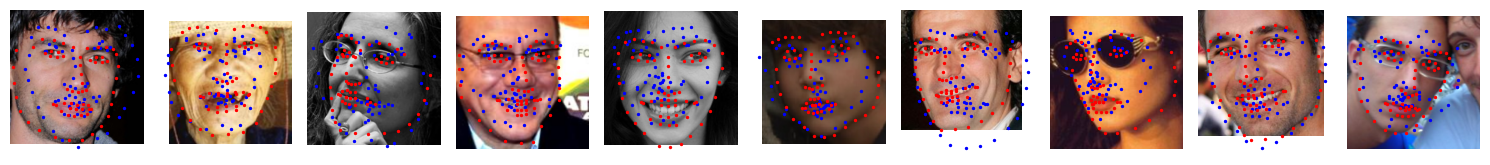

In [213]:
predictions_np = val_pred.detach().cpu().numpy()
pred_np_reshape = predictions_np.reshape(112, 68, 2) * 224

n_samples = 10
fig, axes = plt.subplots(1, n_samples, figsize=(15, 6))

for i in range(n_samples):
    axes[i].imshow(val_imgs[i])
    axes[i].scatter(pred_np_reshape[i, :, 0], pred_np_reshape[i, :, 1], c='b', s=2)
    axes[i].scatter(val_lms[i, :, 0], val_lms[i, :, 1], c='r', s=2)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"sample_output_{checkpoint_name}.png", dpi=300)
plt.show()

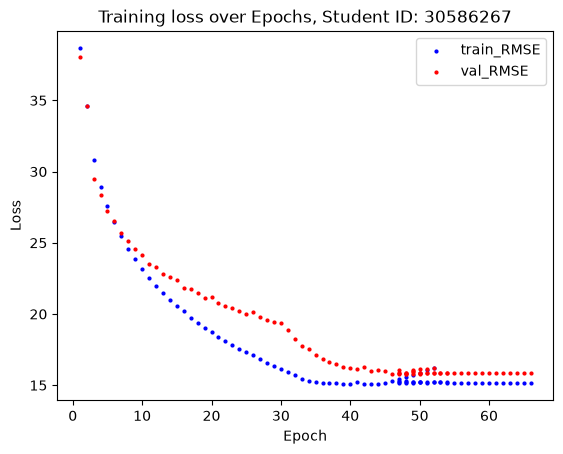

In [151]:
figure1, ax = plt.subplots()
# Y1 = [t.detach().cpu().numpy()*224 for t in history["train_RMSE"]] 
# Y2 = [t.detach().cpu().numpy()*224 for t in history["val_RMSE"]]

# ax.plot(history["Epoch"], Y1, c='b', label="train_RMSE")
# ax.plot(history["Epoch"], Y2, c='r', label="val_RMSE")

ax.scatter(history["Epoch"], [y*224 for y in history["train_RMSE"]], c='b', s=4, label="train_RMSE")
ax.scatter(history["Epoch"], [y*224 for y in history["val_RMSE"]], c='r', s=4, label="val_RMSE")
plt.title("Training loss over Epochs, Student ID: 30586267")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"History{version}.png", dpi=300)
plt.show()

In [160]:
version = "15-4-8"

In [153]:
history = {
    "Epoch": [],
    "train_RMSE": [],
    "val_RMSE": [],
}

In [164]:
frozen = 4

for param in backbone.features[frozen:9].parameters():
    param.requires_grad = True

for param in backbone.features[0:frozen].parameters():
    param.requires_grad = False

backbone = backbone.to(device)

backbone_lr= 5e-6
head_lr = backbone_lr * 10

optimiser = torch.optim.AdamW([
    {"params": backbone.features[frozen:9].parameters(), "lr": backbone_lr},
    {"params": backbone.classifier.parameters(), "lr": head_lr},
], weight_decay=4e-2)

In [165]:
train_dataset = FaceDataset(
    train_imgs,
    train_lms,
    normalise,
    augment=True,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=round(680/20),
    shuffle=True
)

train_eval_dataset = FaceDataset(
    train_imgs,
    train_lms,
    normalise,
    augment=False,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=680,
    shuffle=False
)

val_dataset = FaceDataset(
    val_imgs,
    val_lms,
    normalise,
    augment=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=112,
    shuffle=False
)

In [166]:
iters = 50

checkpoint = torch.load("best_checkpoint15-4-7.pth")
backbone.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]
best_RMSE = checkpoint["val_loss"]
# optimiser.load_state_dict(checkpoint["optimizer_state"])
# torch.save({
#     "epoch": epoch,
#     "model_state": backbone.state_dict(),
#     "optimizer_state": optimiser.state_dict(),
#     "val_loss": val_RMSE,
#     "unfrozen": unfrozen,
#     "history": history,
# }, f"best_checkpoint{version}.pth")
# print(f"Initial version of {version} saved")
# print(f"Epoch: {epoch}")
# print(f"best_RMSE: {best_RMSE*224:.4f}")

# epoch = 0
# best_RMSE = 1000


for i in range(iters):
    epoch = epoch + 1
    
    backbone.classifier.train()
    backbone.features[frozen:9].train()
    backbone.features[0:frozen].eval()
    for m in backbone.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()

    for imgs, landmarks in train_loader:
        imgs = imgs.to(device)
        landmarks = landmarks.to(device)
    
        optimiser.zero_grad()
    
        train_pred = backbone(imgs)
        train_MSE = loss(train_pred, landmarks)
    
        train_MSE.backward()
        optimiser.step()
        
    backbone.eval()
    
    with torch.no_grad():
        for imgs, landmarks in train_eval_loader:
            imgs = imgs.to(device)
            landmarks = landmarks.to(device)
        
            train_pred = backbone(imgs)
            train_MSE = loss(train_pred, landmarks)
            
            train_RMSE = torch.sqrt(train_MSE)
    
    print(f"Iter: {i}    Epoch: {epoch}")
    print(f"train_RMSE: {train_RMSE*224:.4f}")

    
    with torch.no_grad():
        for imgs, landmarks in val_loader:
            imgs = imgs.to(device)
            landmarks = landmarks.to(device)
        
            val_pred = backbone(imgs)
            val_MSE = loss(val_pred, landmarks)
            
            val_RMSE = torch.sqrt(val_MSE)
    print(f"val_RMSE: {val_RMSE*224:.4f}    best_RMSE: {best_RMSE*224:.4f}")
    
    history["Epoch"].append(epoch)
    history["train_RMSE"].append(train_RMSE.item())
    history["val_RMSE"].append(val_RMSE.item())
    
    if val_RMSE < best_RMSE:
        best_RMSE = val_RMSE
        torch.save({
            "epoch": epoch,
            "model_state": backbone.state_dict(),
            "optimizer_state": optimiser.state_dict(),
            "val_loss": val_RMSE,
            "frozen": frozen,
            "history": history,
        }, f"best_checkpoint{version}.pth")
        print("Saved as best")
    # else:
    #     checkpoint = torch.load(f"best_checkpoint{version}.pth")
    #     backbone.load_state_dict(checkpoint["model_state"])
    #     # optimiser.load_state_dict(checkpoint["optimizer_state"])
    #     epoch = checkpoint["epoch"]
    #     best_RMSE = checkpoint["val_loss"]
    
    print("-----------------------")


Iter: 0    Epoch: 542
train_RMSE: 4.1583
val_RMSE: 4.6497    best_RMSE: 4.5956
-----------------------
Iter: 1    Epoch: 543
train_RMSE: 4.1384
val_RMSE: 4.6500    best_RMSE: 4.5956
-----------------------
Iter: 2    Epoch: 544
train_RMSE: 4.1203
val_RMSE: 4.6204    best_RMSE: 4.5956
-----------------------
Iter: 3    Epoch: 545
train_RMSE: 4.0967
val_RMSE: 4.6444    best_RMSE: 4.5956
-----------------------
Iter: 4    Epoch: 546
train_RMSE: 4.0949
val_RMSE: 4.6528    best_RMSE: 4.5956
-----------------------
Iter: 5    Epoch: 547
train_RMSE: 4.1285
val_RMSE: 4.6510    best_RMSE: 4.5956
-----------------------
Iter: 6    Epoch: 548
train_RMSE: 4.1118
val_RMSE: 4.6311    best_RMSE: 4.5956
-----------------------
Iter: 7    Epoch: 549
train_RMSE: 4.1059
val_RMSE: 4.6346    best_RMSE: 4.5956
-----------------------
Iter: 8    Epoch: 550
train_RMSE: 4.1037
val_RMSE: 4.6445    best_RMSE: 4.5956
-----------------------
Iter: 9    Epoch: 551
train_RMSE: 4.0719
val_RMSE: 4.6018    best_RMSE: 4

KeyboardInterrupt: 

In [167]:
checkpoint_name = "best_checkpoint15-4-7.pth"
checkpoint = torch.load(checkpoint_name)
backbone.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]

# history = checkpoint["history"]

with torch.no_grad():
    for imgs, landmarks in val_loader:
        imgs = imgs.to(device)
        landmarks = landmarks.to(device)
    
        val_pred = backbone(imgs)
        val_MSE = loss(val_pred, landmarks)
            
        val_RMSE = torch.sqrt(val_MSE)
print(f"Epoch: {epoch}")
print(f"best_RMSE: {best_RMSE*224:.4f}")
print(val_RMSE.item() * 224)
print(checkpoint["val_loss"].item() * 224)

Epoch: 541
best_RMSE: 4.5956
4.595637142658234
4.595637142658234


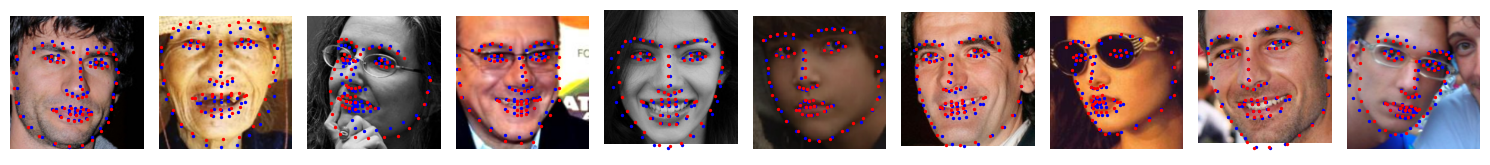

In [168]:
predictions_np = val_pred.detach().cpu().numpy()
pred_np_reshape = predictions_np.reshape(112, 68, 2) * 224

n_samples = 10
fig, axes = plt.subplots(1, n_samples, figsize=(15, 6))

for i in range(n_samples):
    axes[i].imshow(val_imgs[i])
    axes[i].scatter(pred_np_reshape[i, :, 0], pred_np_reshape[i, :, 1], c='b', s=2)
    axes[i].scatter(val_lms[i, :, 0], val_lms[i, :, 1], c='r', s=2)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"sample_output_{checkpoint_name}.png", dpi=300)
plt.show()

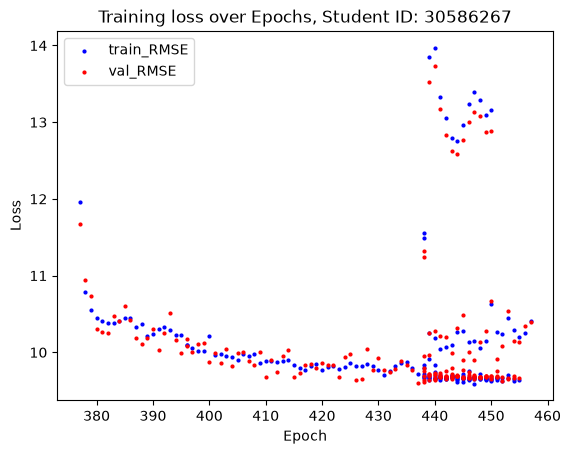

In [110]:
figure1, ax = plt.subplots()
# Y1 = [t.detach().cpu().numpy()*224 for t in history["train_RMSE"]] 
# Y2 = [t.detach().cpu().numpy()*224 for t in history["val_RMSE"]]

# ax.plot(history["Epoch"], Y1, c='b', label="train_RMSE")
# ax.plot(history["Epoch"], Y2, c='r', label="val_RMSE")

ax.scatter(history["Epoch"], [y*224 for y in history["train_RMSE"]], c='b', s=4, label="train_RMSE")
ax.scatter(history["Epoch"], [y*224 for y in history["val_RMSE"]], c='r', s=4, label="val_RMSE")
plt.title("Training loss over Epochs, Student ID: 30586267")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"History_{version}.png", dpi=300)
plt.show()

In [111]:
version = "15-4-4"

In [112]:
history = {
    "Epoch": [],
    "train_RMSE": [],
    "val_RMSE": [],
}

In [122]:
frozen = [0,1,2,3,4,5,7,8]

for param in backbone.features.parameters():
    param.requires_grad = True

for i in frozen:
    for param in backbone.features[i].parameters():
        param.requires_grad = False

backbone = backbone.to(device)

backbone_lr = 1e-5
head_lr = backbone_lr * 10

optimiser = torch.optim.AdamW([
    {"params": backbone.features.parameters(), "lr": backbone_lr},
    {"params": backbone.classifier.parameters(), "lr": head_lr},
], weight_decay=2e+1)

In [123]:
train_dataset = FaceDataset(
    train_imgs,
    train_lms,
    normalise,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=round(680/10),
    shuffle=True
)

train_eval_dataset = FaceDataset(
    train_imgs,
    train_lms,
    normalise,
    augment=False,
)

train_eval_loader = DataLoader(
    train_eval_dataset,
    batch_size=680,
    shuffle=False
)

val_dataset = FaceDataset(
    val_imgs,
    val_lms,
    normalise,
    augment=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=112,
    shuffle=False
)

In [ ]:
iters = 25

checkpoint = torch.load("best_checkpoint15-4-3.pth")
backbone.load_state_dict(checkpoint["model_state"])
epoch = checkpoint["epoch"]
best_RMSE = checkpoint["val_loss"]
# optimiser.load_state_dict(checkpoint["optimizer_state"])
# torch.save({
#     "epoch": epoch,
#     "model_state": backbone.state_dict(),
#     "optimizer_state": optimiser.state_dict(),
#     "val_loss": val_RMSE,
#     "unfrozen": unfrozen,
#     "history": history,
# }, f"best_checkpoint{version}.pth")
# print(f"Initial version of {version} saved")
# print(f"Epoch: {epoch}")
# print(f"best_RMSE: {best_RMSE*224:.4f}")

# epoch = 0
# best_RMSE = 1000


for i in range(iters):
    epoch = epoch + 1
    
    backbone.classifier.train()
    backbone.features.train()
    for j in frozen:
        backbone.features[j].eval()
    for m in backbone.modules():
        if isinstance(m, torch.nn.BatchNorm2d):
            m.eval()

    for imgs, landmarks in train_loader:
        imgs = imgs.to(device)
        landmarks = landmarks.to(device)
    
        optimiser.zero_grad()
    
        train_pred = backbone(imgs)
        train_MSE = loss(train_pred, landmarks)
    
        train_MSE.backward()
        optimiser.step()
        
    backbone.eval()
    
    with torch.no_grad():
        for imgs, landmarks in train_eval_loader:
            imgs = imgs.to(device)
            landmarks = landmarks.to(device)
        
            train_pred = backbone(imgs)
            train_MSE = loss(train_pred, landmarks)
            
            train_RMSE = torch.sqrt(train_MSE)
    
    print(f"Iter: {i}    Epoch: {epoch}")
    print(f"train_RMSE: {train_RMSE*224:.4f}")

    
    with torch.no_grad():
        for imgs, landmarks in val_loader:
            imgs = imgs.to(device)
            landmarks = landmarks.to(device)
        
            val_pred = backbone(imgs)
            val_MSE = loss(val_pred, landmarks)
            
            val_RMSE = torch.sqrt(val_MSE)
    print(f"val_RMSE: {val_RMSE*224:.4f}    best_RMSE: {best_RMSE*224:.4f}")
    
    history["Epoch"].append(epoch)
    history["train_RMSE"].append(train_RMSE.item())
    history["val_RMSE"].append(val_RMSE.item())
    
    if val_RMSE < best_RMSE:
        best_RMSE = val_RMSE
        torch.save({
            "epoch": epoch,
            "model_state": backbone.state_dict(),
            "optimizer_state": optimiser.state_dict(),
            "val_loss": val_RMSE,
            "frozen": frozen,
            "history": history,
        }, f"best_checkpoint{version}.pth")
        print("Saved as best")
    # else:
    #     checkpoint = torch.load(f"best_checkpoint{version}.pth")
    #     backbone.load_state_dict(checkpoint["model_state"])
    #     # optimiser.load_state_dict(checkpoint["optimizer_state"])
    #     epoch = checkpoint["epoch"]
    #     best_RMSE = checkpoint["val_loss"]
    
    print("-----------------------")


In [ ]:
predictions_np = val_pred.detach().cpu().numpy()
pred_np_reshape = predictions_np.reshape(112, 68, 2) * 224

n_samples = 10
fig, axes = plt.subplots(1, n_samples, figsize=(15, 6))

for i in range(n_samples):
    axes[i].imshow(val_imgs[i])
    axes[i].scatter(pred_np_reshape[i, :, 0], pred_np_reshape[i, :, 1], c='b', s=2)
    axes[i].scatter(val_lms[i, :, 0], val_lms[i, :, 1], c='r', s=2)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig(f"sample_output_{checkpoint_name}.png", dpi=300)
plt.show()

In [ ]:
figure1, ax = plt.subplots()

ax.scatter(history["Epoch"], [y*224 for y in history["train_RMSE"]], c='b', s=4, label="train_RMSE")
ax.scatter(history["Epoch"], [y*224 for y in history["val_RMSE"]], c='r', s=4, label="val_RMSE")
plt.title("Training loss over Epochs, Student ID: 30586267")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f"History_{version}.png", dpi=300)
plt.show()